In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures standardized with zero mean and unit variance.")

Dataset Shape: (569, 30)
Target Distribution:
target
1    357
0    212
Name: count, dtype: int64

Features standardized with zero mean and unit variance.


Components needed to explain >=95% variance: 10

--- TABLE 1: PCA SUMMARY SETTING ---
 Chosen Components  Variance Target (%)  Explained Variance (%)                                                          Justification
                10                 95.0                   95.16 Captures 95% variance while reducing feature dimensions from 30 to 10.


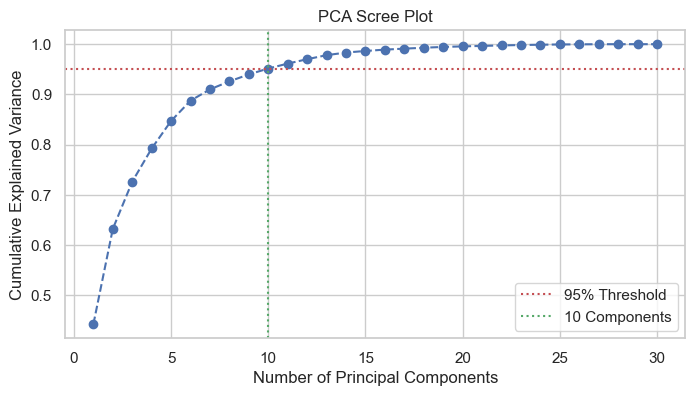

In [7]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Components needed to explain >=95% variance: {n_components_95}")

pca_95 = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca = pca_95.fit_transform(X_scaled)

table1 = pd.DataFrame([{
    'Chosen Components': n_components_95,
    'Variance Target (%)': 95.0,
    'Explained Variance (%)': round(np.sum(pca_95.explained_variance_ratio_) * 100, 2),
    'Justification': 'Captures 95% variance while reducing feature dimensions from 30 to 10.'
}])
print("\n--- TABLE 1: PCA SUMMARY SETTING ---")
print(table1.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Threshold')
plt.axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.legend(loc='lower right')
plt.show()

In [8]:
base_stack = [
    ('knn', KNeighborsClassifier()),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE))
]

models_config = {
    'SVM': (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
    ),
    'Naïve Bayes': (
        GaussianNB(),
        {'var_smoothing': [1e-9, 1e-8, 1e-7]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
    ),
    'Logistic Regression': (
        LogisticRegression(random_state=RANDOM_STATE),
        {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'max_depth': [3, 5, 10, None], 'criterion': ['gini', 'entropy']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [30, 50, 100], 'learning_rate': [0.01, 0.1, 1.0]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    ),
    'XGBoost': (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
        {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    ),
    'Stacking': (
        StackingClassifier(estimators=base_stack, final_estimator=LogisticRegression(random_state=RANDOM_STATE)),
        {'final_estimator__C': [0.1, 1.0, 10.0]}
    )
}

print("Configured 10 classifiers and hyperparameter search spaces.")

Configured 10 classifiers and hyperparameter search spaces.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_results_no_pca = {}
fold_results_with_pca = {}
best_estimators_no_pca = {}
best_estimators_with_pca = {}

for name, (model, grid) in models_config.items():
    print(f"Evaluating: {name}...")

    gs_no = GridSearchCV(model, grid, cv=cv, scoring='f1', n_jobs=-1)
    gs_no.fit(X_scaled, y)
    best_no = gs_no.best_estimator_
    best_estimators_no_pca[name] = best_no

    folds_no = []
    for train_idx, val_idx in cv.split(X_scaled, y):
        m = gs_no.best_estimator_
        m.fit(X_scaled[train_idx], y.iloc[train_idx])
        pred = m.predict(X_scaled[val_idx])
        folds_no.append(f1_score(y.iloc[val_idx], pred))
    fold_results_no_pca[name] = folds_no

    gs_pca = GridSearchCV(model, grid, cv=cv, scoring='f1', n_jobs=-1)
    gs_pca.fit(X_pca, y)
    best_pca = gs_pca.best_estimator_
    best_estimators_with_pca[name] = best_pca

    folds_pca = []
    for train_idx, val_idx in cv.split(X_pca, y):
        m = gs_pca.best_estimator_
        m.fit(X_pca[train_idx], y.iloc[train_idx])
        pred = m.predict(X_pca[val_idx])
        folds_pca.append(f1_score(y.iloc[val_idx], pred))
    fold_results_with_pca[name] = folds_pca

print("\nCross-validation finished!")

Evaluating: SVM...
Evaluating: Naïve Bayes...
Evaluating: KNN...
Evaluating: Logistic Regression...
Evaluating: Decision Tree...
Evaluating: Random Forest...
Evaluating: AdaBoost...
Evaluating: Gradient Boosting...
Evaluating: XGBoost...
Evaluating: Stacking...

Cross-validation finished!


In [10]:
rows = []
for name in models_config.keys():

    fn = fold_results_no_pca[name]
    avg_no = np.mean(fn)
    

    fp = fold_results_with_pca[name]
    avg_pca = np.mean(fp)
    
    rows.append({
        'Model': name,
        'Fold 1 (No)': round(fn[0], 4), 'Fold 2 (No)': round(fn[1], 4), 'Fold 3 (No)': round(fn[2], 4),
        'Fold 4 (No)': round(fn[3], 4), 'Fold 5 (No)': round(fn[4], 4), 'Avg (No-PCA)': round(avg_no, 4),
        'Fold 1 (PCA)': round(fp[0], 4), 'Fold 2 (PCA)': round(fp[1], 4), 'Fold 3 (PCA)': round(fp[2], 4),
        'Fold 4 (PCA)': round(fp[3], 4), 'Fold 5 (PCA)': round(fp[4], 4), 'Avg (With-PCA)': round(avg_pca, 4)
    })

table5 = pd.DataFrame(rows)
print("\n--- TABLE 5: 5-FOLD CROSS-VALIDATION RESULTS (F1-SCORE) ---")
print(table5[['Model', 'Fold 1 (No)', 'Fold 2 (No)', 'Fold 3 (No)', 'Fold 4 (No)', 'Fold 5 (No)', 'Avg (No-PCA)']].to_string(index=False))
print("\n--- WITH PCA ---")
print(table5[['Model', 'Fold 1 (PCA)', 'Fold 2 (PCA)', 'Fold 3 (PCA)', 'Fold 4 (PCA)', 'Fold 5 (PCA)', 'Avg (With-PCA)']].to_string(index=False))


--- TABLE 5: 5-FOLD CROSS-VALIDATION RESULTS (F1-SCORE) ---
              Model  Fold 1 (No)  Fold 2 (No)  Fold 3 (No)  Fold 4 (No)  Fold 5 (No)  Avg (No-PCA)
                SVM       0.9929       0.9718       0.9730       0.9930       0.9861        0.9834
        Naïve Bayes       0.9650       0.9315       0.9467       0.9197       0.9583        0.9442
                KNN       0.9930       0.9660       0.9660       0.9859       0.9660        0.9754
Logistic Regression       0.9859       0.9726       0.9730       0.9930       0.9930        0.9835
      Decision Tree       0.9429       0.9324       0.9793       0.9571       0.9444        0.9512
      Random Forest       0.9714       0.9524       0.9660       0.9565       0.9790        0.9651
           AdaBoost       0.9930       0.9517       0.9660       0.9787       0.9793        0.9738
  Gradient Boosting       0.9577       0.9722       0.9660       0.9650       0.9510        0.9624
            XGBoost       0.9857       0.9524   

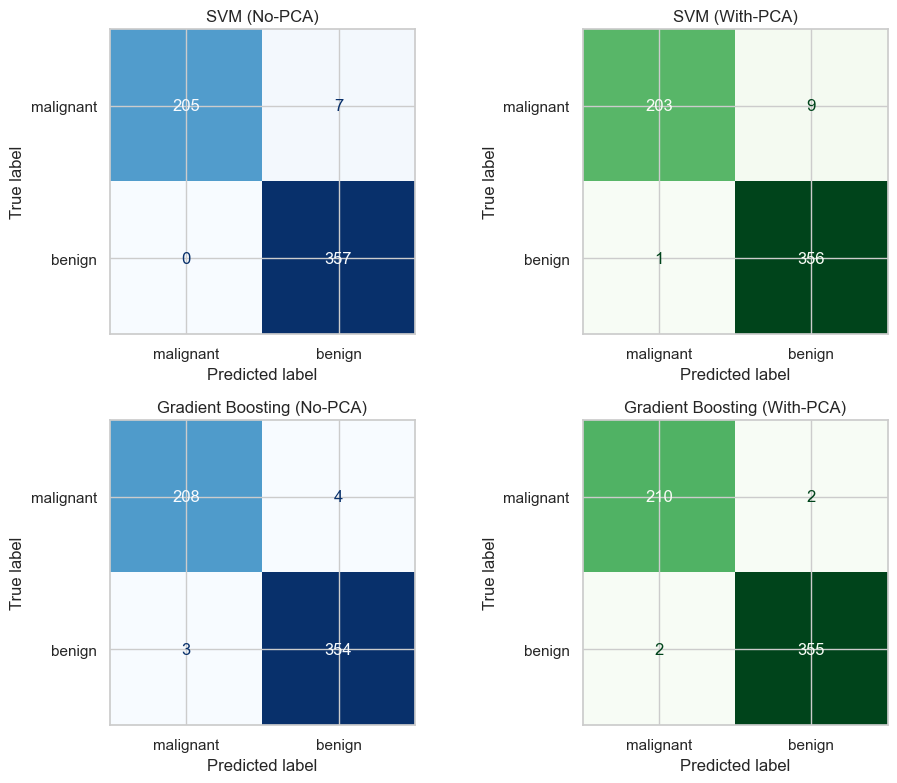

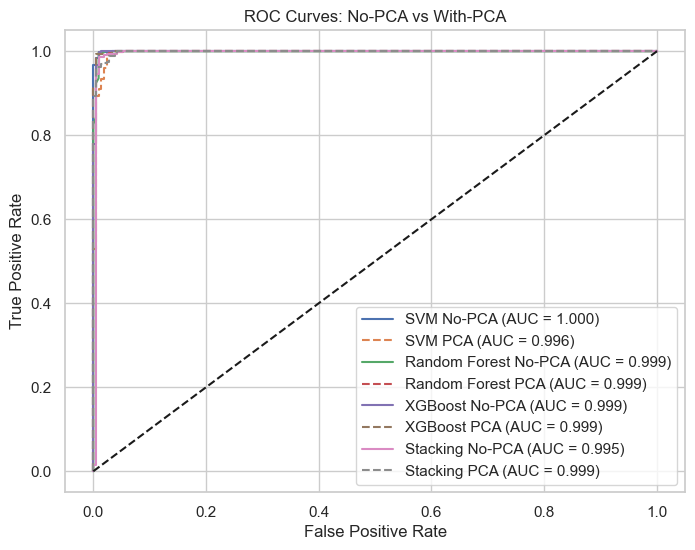

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
selected = ['SVM', 'Gradient Boosting']

for i, name in enumerate(selected):

    pred_no = best_estimators_no_pca[name].predict(X_scaled)
    cm_no = confusion_matrix(y, pred_no)
    disp_no = ConfusionMatrixDisplay(confusion_matrix=cm_no, display_labels=data.target_names)
    disp_no.plot(ax=axes[i, 0], cmap='Blues', colorbar=False)
    axes[i, 0].set_title(f"{name} (No-PCA)")

    pred_pca = best_estimators_with_pca[name].predict(X_pca)
    cm_pca = confusion_matrix(y, pred_pca)
    disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=data.target_names)
    disp_pca.plot(ax=axes[i, 1], cmap='Greens', colorbar=False)
    axes[i, 1].set_title(f"{name} (With-PCA)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name in ['SVM', 'Random Forest', 'XGBoost', 'Stacking']:
    m_no = best_estimators_no_pca[name]
    m_pca = best_estimators_with_pca[name]
    
    probs_no = m_no.predict_proba(X_scaled)[:, 1] if hasattr(m_no, "predict_proba") else m_no.decision_function(X_scaled)
    probs_pca = m_pca.predict_proba(X_pca)[:, 1] if hasattr(m_pca, "predict_proba") else m_pca.decision_function(X_pca)
    
    fpr_no, tpr_no, _ = roc_curve(y, probs_no)
    fpr_pca, tpr_pca, _ = roc_curve(y, probs_pca)
    
    plt.plot(fpr_no, tpr_no, label=f'{name} No-PCA (AUC = {auc(fpr_no, tpr_no):.3f})')
    plt.plot(fpr_pca, tpr_pca, linestyle='--', label=f'{name} PCA (AUC = {auc(fpr_pca, tpr_pca):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: No-PCA vs With-PCA')
plt.legend(loc='lower right')
plt.show()